In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("Advertising.csv")

In [3]:
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [5]:
df.drop("Unnamed: 0", axis = 1, inplace= True)

In [6]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [11]:
df.shape

(200, 4)

In [13]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [14]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [15]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


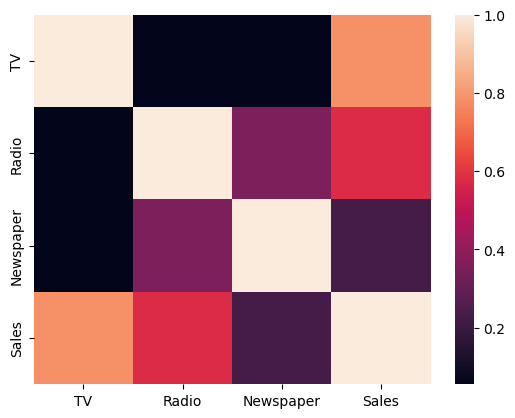

In [16]:
sns.heatmap(df.corr())
plt.show()

In [17]:
# dependent and independet features
X = df.drop("Sales", axis=1)
y = df["Sales"]

In [18]:
X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [19]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64

In [28]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15, random_state=15)

In [33]:
X_train.shape

(170, 3)

In [34]:
X_train.corr()

,TV,Radio,Newspaper
TV,1.000000,0.022454,0.030723
Radio,0.022454,1.000000,0.359098
Newspaper,0.030723,0.359098,1.000000


In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [43]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

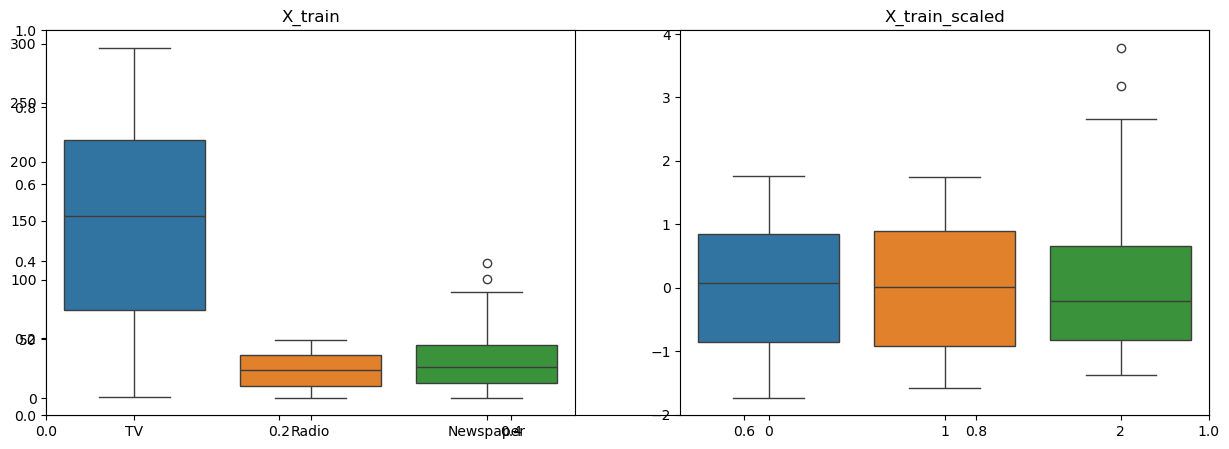

In [44]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data = X_train)
plt.title("X_train")
plt.subplot(1,2,2)
sns.boxplot(data = X_train_scaled)
plt.title("X_train_scaled")
plt.show()

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Mean Absoulute Error:  1.3498345957251359
Mean Square Error:  2.528248602374875
R2_Score:  0.9188049261017142


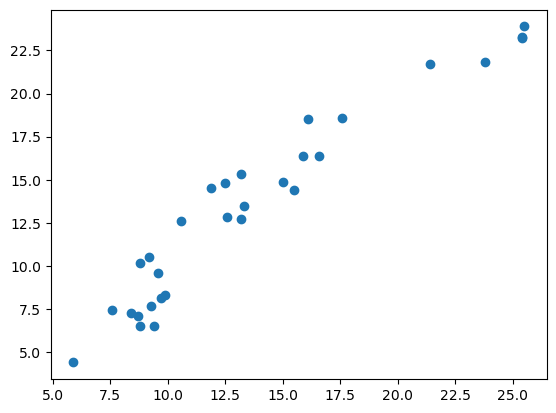

In [46]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absoulute Error: ", mae)
print("Mean Square Error: " ,mse)
print("R2_Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absoulute Error:  1.51755826816455
Mean Square Error:  4.5087872085511655
R2_Score:  0.855199638893867


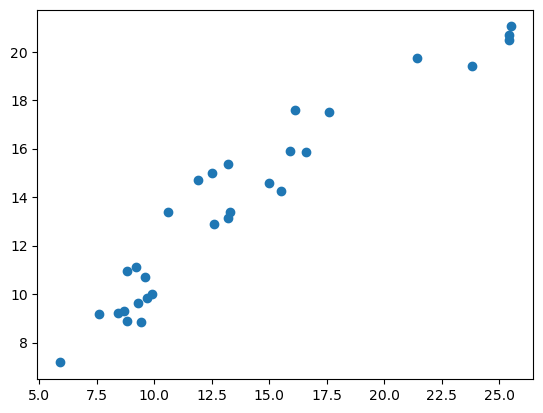

In [47]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absoulute Error: ", mae)
print("Mean Square Error: " ,mse)
print("R2_Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absoulute Error:  1.3454261176665858
Mean Square Error:  2.5189015903882077
R2_Score:  0.9191051067596893


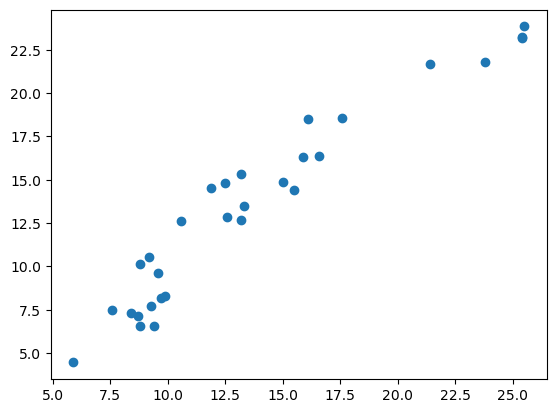

In [48]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absoulute Error: ", mae)
print("Mean Square Error: " ,mse)
print("R2_Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absoulute Error:  2.044981893661196
Mean Square Error:  7.059282227653758
R2_Score:  0.7732901180663976


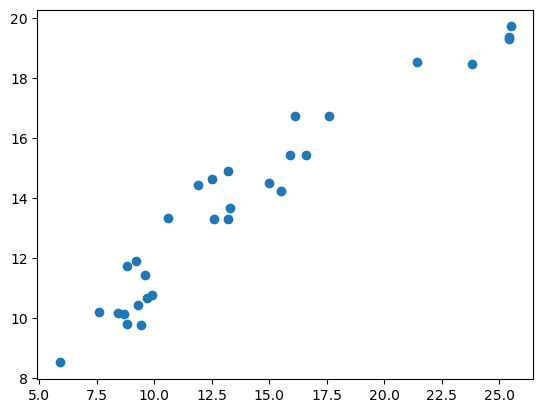

In [49]:
from sklearn.linear_model import ElasticNet
elasticnet = ElasticNet()
elasticnet.fit(X_train_scaled, y_train)
y_pred = elasticnet.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absoulute Error: ", mae)
print("Mean Square Error: " ,mse)
print("R2_Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

In [50]:
# lasso cross validation

In [52]:
from sklearn.linear_model import LassoCV

Mean Absoulute Error:  1.3265211121622014
Mean Square Error:  2.472272163407726
R2_Score:  0.9206026176318236


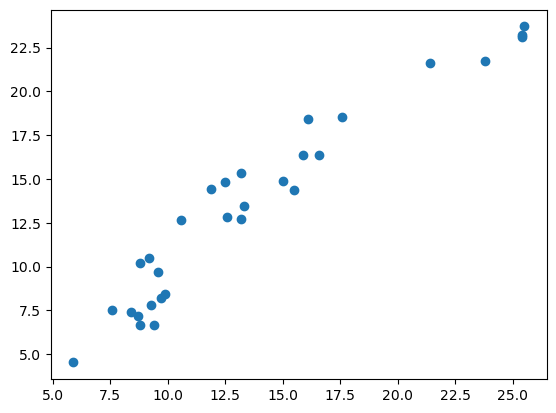

In [53]:
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled, y_train)
y_pred = lassocv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absoulute Error: ", mae)
print("Mean Square Error: " ,mse)
print("R2_Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absoulute Error:  1.3454261176665858
Mean Square Error:  2.5189015903882077
R2_Score:  0.9191051067596893


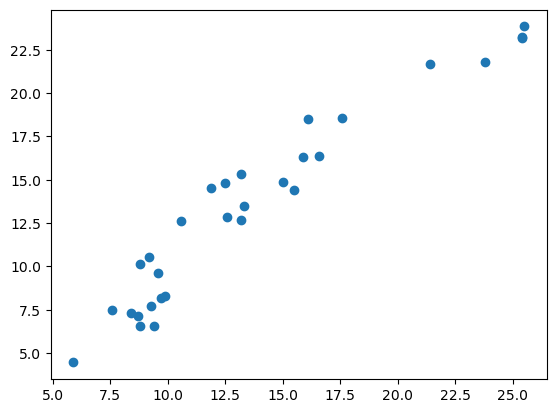

In [54]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_scaled, y_train)
y_pred = ridgecv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absoulute Error: ", mae)
print("Mean Square Error: " ,mse)
print("R2_Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absoulute Error:  1.3396836404877035
Mean Square Error:  2.5062507132978262
R2_Score:  0.919511391529022


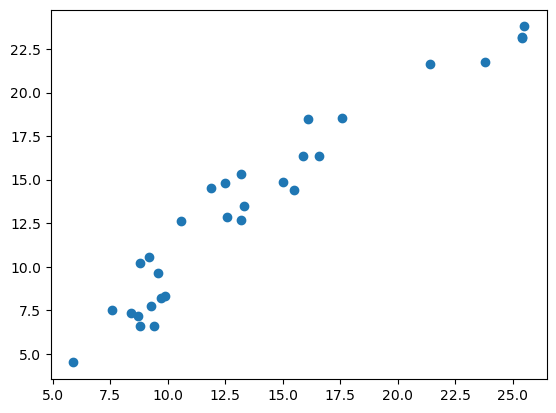

In [55]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv = ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_scaled, y_train)
y_pred = elasticnetcv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absoulute Error: ", mae)
print("Mean Square Error: " ,mse)
print("R2_Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()